In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries Imported Successfully!')

Libraries Imported Successfully!


In [2]:
# Load Dataset
df = pd.read_csv('/content/ecommerce_data.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')
df['month_name'] = df['order_date'].dt.strftime('%b %Y')
df['year'] = df['order_date'].dt.year
df['month_num'] = df['order_date'].dt.month

print('Shape:', df.shape)
df.head()

Shape: (100, 14)


,order_id,customer_id,order_date,product,category,quantity,unit_price,revenue,region,status,month,month_name,year,month_num
0,1001,C001,2024-01-05,Laptop,Electronics,1,55000,55000,North,Completed,2024-01,Jan 2024,2024,1
1,1002,C002,2024-01-07,T-Shirt,Clothing,3,499,1497,South,Completed,2024-01,Jan 2024,2024,1
2,1003,C003,2024-01-10,Headphones,Electronics,2,2999,5998,East,Completed,2024-01,Jan 2024,2024,1
3,1004,C001,2024-01-15,Mouse,Electronics,1,799,799,North,Completed,2024-01,Jan 2024,2024,1
4,1005,C004,2024-01-18,Jeans,Clothing,2,1299,2598,West,Completed,2024-01,Jan 2024,2024,1


In [3]:
# Basic Info
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     100 non-null    int64         
 1   customer_id  100 non-null    object        
 2   order_date   100 non-null    datetime64[ns]
 3   product      100 non-null    object        
 4   category     100 non-null    object        
 5   quantity     100 non-null    int64         
 6   unit_price   100 non-null    int64         
 7   revenue      100 non-null    int64         
 8   region       100 non-null    object        
 9   status       100 non-null    object        
 10  month        100 non-null    period[M]     
 11  month_name   100 non-null    object        
 12  year         100 non-null    int32         
 13  month_num    100 non-null    int32         
dtypes: datetime64[ns](1), int32(2), int64(4), object(6), period[M](1)
memory usage: 10.3+ 

,order_id,order_date,quantity,unit_price,revenue,year,month_num
count,100.000000,100,100.000000,100.000000,100.000000,100.0,100.000000
mean,1050.500000,2024-06-25 03:50:24,1.610000,13314.300000,14221.690000,2024.0,6.370000
min,1001.000000,2024-01-05 00:00:00,1.000000,499.000000,599.000000,2024.0,1.000000
25%,1025.750000,2024-03-22 06:00:00,1.000000,1499.000000,2371.000000,2024.0,3.000000
50%,1050.500000,2024-06-18 12:00:00,1.000000,2499.000000,4498.000000,2024.0,6.000000
75%,1075.250000,2024-09-24 06:00:00,2.000000,18250.000000,18250.000000,2024.0,9.250000
max,1100.000000,2024-12-27 00:00:00,6.000000,70000.000000,70000.000000,2024.0,12.000000
std,29.011492,NaN,1.003982,19566.851638,19123.437596,0.0,3.529543


In [4]:
# KPI 1: Total Revenue
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()

# KPI 2: Average Order Value (AOV)
aov = total_revenue / total_orders

# KPI 3: Revenue per Customer
rev_per_customer = total_revenue / total_customers

# KPI 4: Avg items per order
avg_qty = df['quantity'].mean()

# KPI 5: Top Category Revenue Share
top_cat = df.groupby('category')['revenue'].sum()
top_cat_share = (top_cat.max() / total_revenue) * 100

print('=' * 45)
print('CORE KPI DASHBOARD')
print('=' * 45)
print(f' Total Revenue        : ₹{total_revenue:,.0f}')
print(f' Total Orders         : {total_orders}')
print(f' Total Customers      : {total_customers}')
print(f' Avg Order Value      : ₹{aov:,.0f}')
print(f' Revenue/Customer     : ₹{rev_per_customer:,.0f}')
print(f' Avg Qty per Order    : {avg_qty:.2f}')
print(f' Top Category Share   : {top_cat_share:.1f}%')
print('=' * 45)

CORE KPI DASHBOARD
 Total Revenue        : ₹1,422,169
 Total Orders         : 100
 Total Customers      : 49
 Avg Order Value      : ₹14,222
 Revenue/Customer     : ₹29,024
 Avg Qty per Order    : 1.61
 Top Category Share   : 87.5%


In [10]:
import os

# Create folder if it doesn't exist
os.makedirs('dashboard', exist_ok=True)

plt.tight_layout()
plt.savefig('dashboard/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

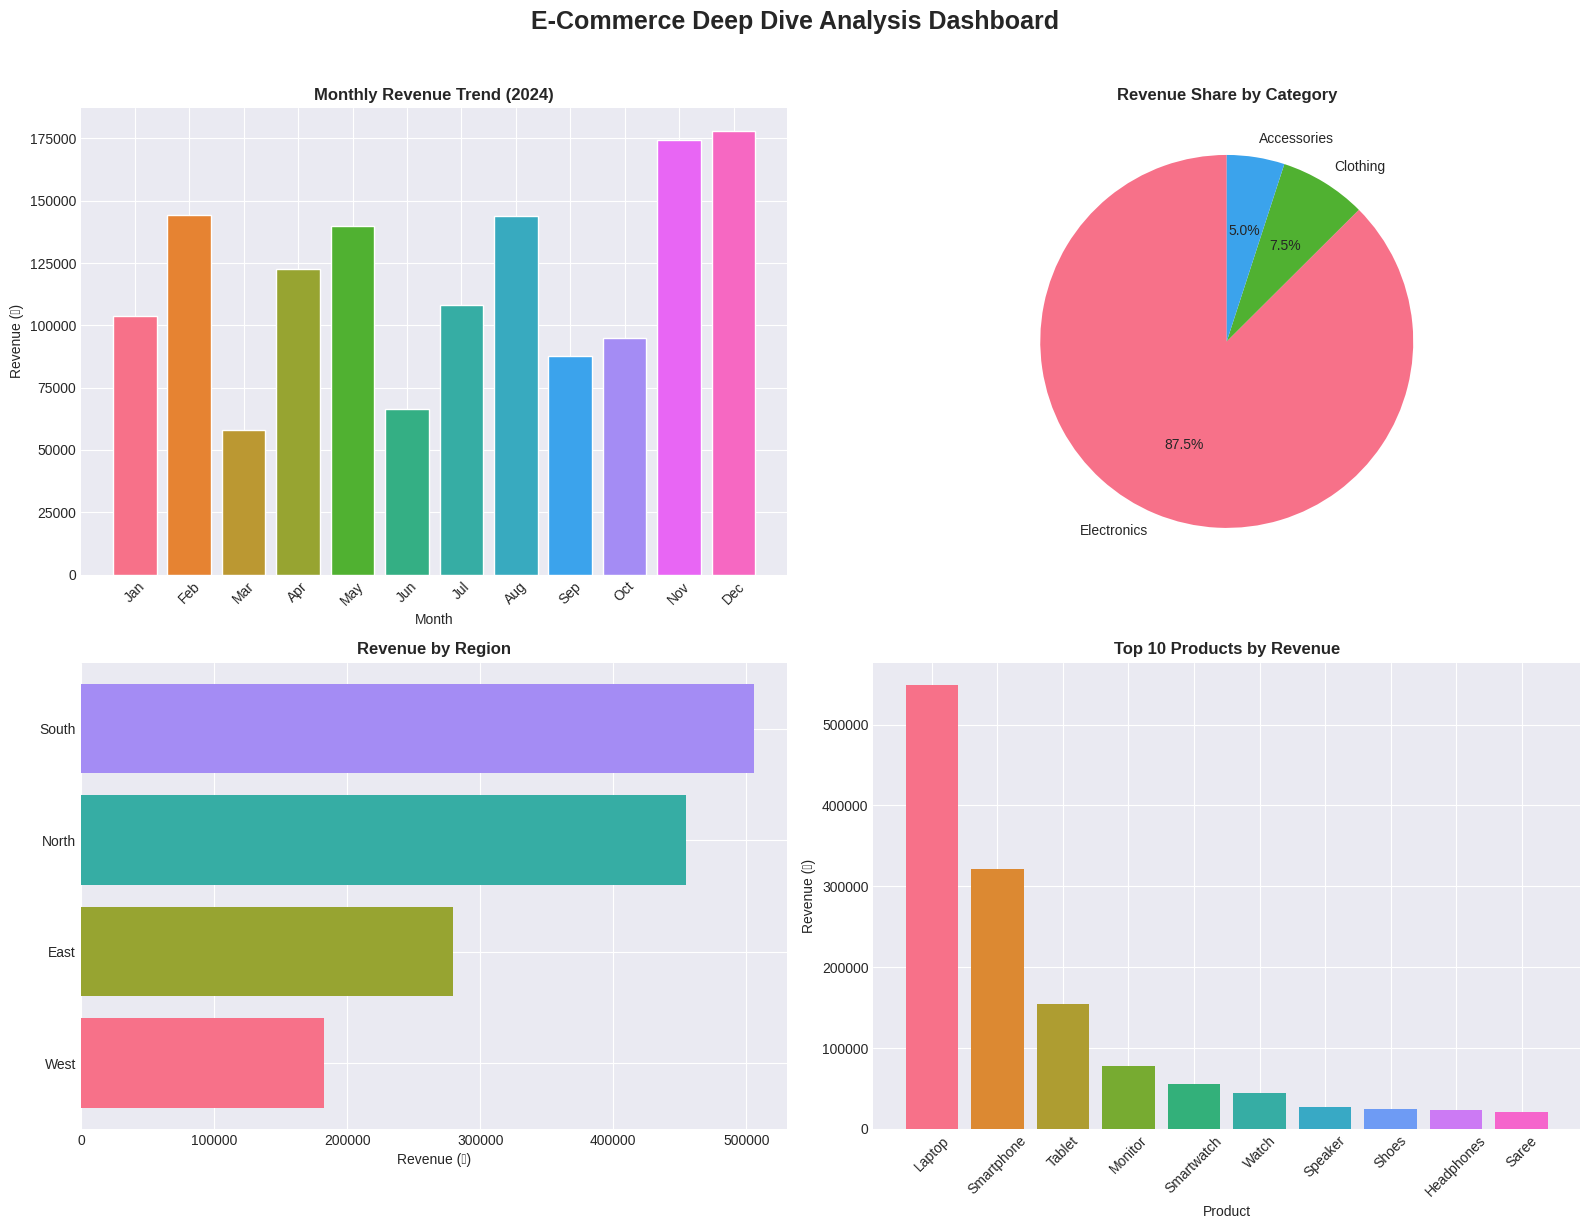

EDA Overview saved!


In [11]:
# =============================================
# VISUALIZATION 1: Monthly Revenue Trend
# =============================================
monthly_rev = df.groupby('month_num')['revenue'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Deep Dive Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)

# Plot 1: Monthly Revenue
axes[0,0].bar(month_labels, monthly_rev['revenue'], color=sns.color_palette('husl', 12), edgecolor='white')
axes[0,0].set_title('Monthly Revenue Trend (2024)', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue (₹)')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Revenue by Category
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
axes[0,1].pie(cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette('husl', len(cat_rev)))
axes[0,1].set_title('Revenue Share by Category', fontweight='bold')

# Plot 3: Revenue by Region
region_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=True)
axes[1,0].barh(region_rev.index, region_rev.values, color=sns.color_palette('husl', 4))
axes[1,0].set_title('Revenue by Region', fontweight='bold')
axes[1,0].set_xlabel('Revenue (₹)')
# Plot 4: Top 10 Products
top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)
axes[1,1].bar(top_products.index, top_products.values, color=sns.color_palette('husl', 10))
axes[1,1].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[1,1].set_xlabel('Product')
axes[1,1].set_ylabel('Revenue (₹)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('dashboard/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA Overview saved!')

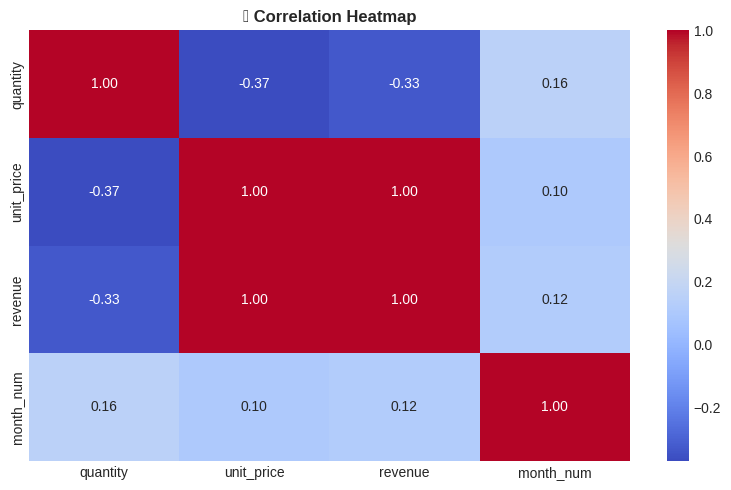

Correlation Heatmap saved!


In [12]:
# =============================================
# CORRELATION HEATMAP
# =============================================
fig, ax = plt.subplots(figsize=(8, 5))
corr = df[['quantity','unit_price','revenue','month_num']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('📈 Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlation Heatmap saved!')